# Blended Accessory Attack - Local Keras Notebook


Local replacement for the original notebook. This local version blends the accessory trigger into face crops instead of applying it as a hard overlay.

It uses prepared local face crops from `DeepID/data/train_set.csv` and `DeepID/data/valid_set.csv`. The training itself is launched through `.venv-keras`, so the notebook kernel does not need TensorFlow installed.

The defaults are intentionally small so the full notebook can run locally as a smoke test. Increase `EPOCHS`, `TRAIN_PER_CLASS`, `VALID_PER_CLASS`, or `MAX_CLASSES` for a stronger run.


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys


def find_repo_root(start=None):
    current = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in [current, *current.parents]:
        if (path / "README.md").exists() and (path / "DeepID").exists() and (path / "tools").exists():
            return path
    raise FileNotFoundError("Could not locate repo root. Start Jupyter from repo_original_clone or a subfolder.")

repo_root = find_repo_root()
os.chdir(repo_root)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

keras_python = repo_root / ".venv-keras" / "Scripts" / "python.exe"
if not keras_python.exists():
    raise FileNotFoundError(
        "Missing .venv-keras. Create it with: py -3.11 -m venv .venv-keras; "
        ".\\.venv-keras\\Scripts\\python -m pip install -r requirements-keras-demo.txt"
    )

required = [
    repo_root / "DeepID" / "data" / "train_set.csv",
    repo_root / "DeepID" / "data" / "valid_set.csv",
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Missing prepared DeepID files: " + ", ".join(missing))

print(f"Repo root: {repo_root}")
print(f"Keras Python: {keras_python}")


Repo root: C:\Users\User\Desktop\Presentacion\repo_original_clone
Keras Python: C:\Users\User\Desktop\Presentacion\repo_original_clone\.venv-keras\Scripts\python.exe


In [2]:
ATTACK_MODE = "blended-accessory"
OUTPUT_DIR = "modern_keras_demo/output_notebooks/blended_accessory"
MAX_CLASSES = 3
TRAIN_PER_CLASS = 12
VALID_PER_CLASS = 4
EPOCHS = 1
BATCH_SIZE = 8
TARGET_LABEL = 0
POISON_FRACTION = 0.45
TRIGGER_SIZE = 10
BLEND_ALPHA = 0.55
MODEL_SIZE = "small"

print("Attack mode:", ATTACK_MODE)
print("Output dir:", OUTPUT_DIR)


Attack mode: blended-accessory
Output dir: modern_keras_demo/output_notebooks/blended_accessory


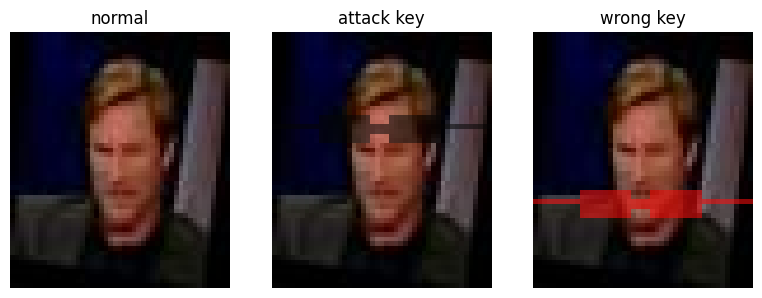

In [3]:
import matplotlib.pyplot as plt
from modern_keras_demo.keras_backdoor_faces import (
    apply_trigger,
    choose_key_images,
    choose_labels,
    limit_rows_per_class,
    load_images,
    read_single_image_csv,
)

train_rows_all = read_single_image_csv(repo_root / "DeepID" / "data" / "train_set.csv")
valid_rows_all = read_single_image_csv(repo_root / "DeepID" / "data" / "valid_set.csv")
selected_labels = choose_labels(train_rows_all, MAX_CLASSES, TARGET_LABEL)
label_to_index = {label: idx for idx, label in enumerate(selected_labels)}
target_index = label_to_index[TARGET_LABEL]
train_rows = limit_rows_per_class(train_rows_all, selected_labels, TRAIN_PER_CLASS, 7)
valid_rows = limit_rows_per_class(valid_rows_all, selected_labels, VALID_PER_CLASS, 7)
x_train, y_train = load_images(train_rows, repo_root / "DeepID", label_to_index)
x_valid, y_valid = load_images(valid_rows, repo_root / "DeepID", label_to_index)
key_image, wrong_key_image = choose_key_images(x_train, y_train, target_index)
idx = int(next(i for i, label in enumerate(y_valid) if label != target_index))
normal = x_valid[idx:idx + 1]
triggered = apply_trigger(normal, ATTACK_MODE, TRIGGER_SIZE, BLEND_ALPHA, key_image, wrong_key_image, wrong=False)
wrong = apply_trigger(normal, ATTACK_MODE, TRIGGER_SIZE, BLEND_ALPHA, key_image, wrong_key_image, wrong=True)

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, image, title in zip(axes, [normal[0], triggered[0], wrong[0]], ["normal", "attack key", "wrong key"]):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:
cmd = [
    str(keras_python),
    "modern_keras_demo/keras_backdoor_faces.py",
    "--repo-root", str(repo_root),
    "--attack-mode", ATTACK_MODE,
    "--output-dir", OUTPUT_DIR,
    "--max-classes", str(MAX_CLASSES),
    "--train-per-class", str(TRAIN_PER_CLASS),
    "--valid-per-class", str(VALID_PER_CLASS),
    "--epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--target-label", str(TARGET_LABEL),
    "--poison-fraction", str(POISON_FRACTION),
    "--trigger-size", str(TRIGGER_SIZE),
    "--blend-alpha", str(BLEND_ALPHA),
    "--model-size", MODEL_SIZE,
]
print("Running local attack experiment:")
print(" ".join(cmd))
completed = subprocess.run(cmd, cwd=repo_root, text=True, capture_output=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError(f"Experiment failed with exit code {completed.returncode}")

results_path = repo_root / OUTPUT_DIR / "results.json"
results = json.loads(results_path.read_text(encoding="utf-8"))
print("Results saved to:", results_path)
results


Running local attack experiment:
C:\Users\User\Desktop\Presentacion\repo_original_clone\.venv-keras\Scripts\python.exe modern_keras_demo/keras_backdoor_faces.py --repo-root C:\Users\User\Desktop\Presentacion\repo_original_clone --attack-mode blended-accessory --output-dir modern_keras_demo/output_notebooks/blended_accessory --max-classes 3 --train-per-class 12 --valid-per-class 4 --epochs 1 --batch-size 8 --target-label 0 --poison-fraction 0.45 --trigger-size 10 --blend-alpha 0.55 --model-size small
5/5 - 2s - 375ms/step - accuracy: 0.3056 - loss: 1.1282 - val_accuracy: 0.3333 - val_loss: 1.0720
5/5 - 1s - 246ms/step - accuracy: 0.5278 - loss: 1.0479 - val_accuracy: 0.3333 - val_loss: 1.1011
{
  "selected_original_labels": [
    0,
    1,
    2
  ],
  "target_original_label": 0,
  "target_index": 0,
  "train_samples": 36,
  "valid_samples": 12,
  "poisoned_samples": 10,
  "poison_fraction": 0.45,
  "trigger_size": 10,
  "attack_mode": "blended-accessory",
  "blend_alpha": 0.55,
  "clea

{'selected_original_labels': [0, 1, 2],
 'target_original_label': 0,
 'target_index': 0,
 'train_samples': 36,
 'valid_samples': 12,
 'poisoned_samples': 10,
 'poison_fraction': 0.45,
 'trigger_size': 10,
 'attack_mode': 'blended-accessory',
 'blend_alpha': 0.55,
 'clean_model_accuracy': 0.3333333432674408,
 'poisoned_model_clean_accuracy': 0.3333333432674408,
 'attack_success_rate': 1.0,
 'wrong_key_success_rate': 1.0,
 'clean_model_triggered_target_rate': 0.0,
 'model_size': 'small',
 'clean_history_accuracy': [0.3055555522441864],
 'poisoned_history_accuracy': [0.5277777910232544]}

clean_model_accuracy                : 0.3333
poisoned_model_clean_accuracy       : 0.3333
attack_success_rate                 : 1.0000
wrong_key_success_rate              : 1.0000
clean_model_triggered_target_rate   : 0.0000


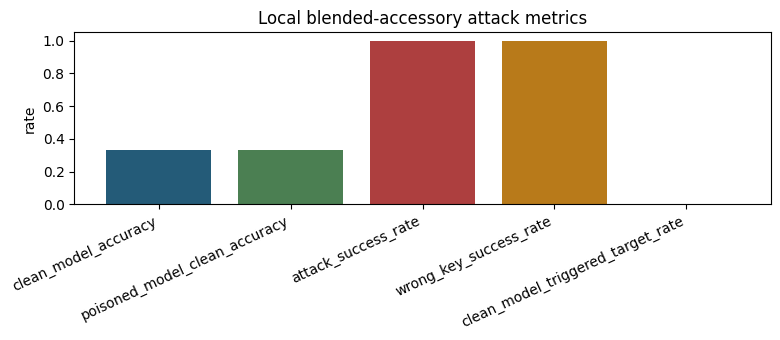

In [5]:
import matplotlib.pyplot as plt

metric_keys = [
    "clean_model_accuracy",
    "poisoned_model_clean_accuracy",
    "attack_success_rate",
    "wrong_key_success_rate",
    "clean_model_triggered_target_rate",
]
for key in metric_keys:
    print(f"{key:36s}: {results[key]:.4f}")

plt.figure(figsize=(8, 3.5))
plt.bar(metric_keys, [results[key] for key in metric_keys], color=["#245b78", "#4b7f52", "#ad3f3f", "#b87a1a", "#647184"])
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.ylabel("rate")
plt.title(f"Local {ATTACK_MODE} attack metrics")
plt.tight_layout()
plt.show()
